---
title: "Handoffs"
---

[*Hand off*](https://www.merriam-webster.com/dictionary/handoff) (verb): to pass or delegate (a task or responsibility) to another.

The term **handoffs** was coined by [OpenAI](https://openai.github.io/openai-agents-python/handoffs/) for using tool calls (e.g., `transfer_to_sales_agent`) to transfer control between agents or states.

```{mermaid}
sequenceDiagram
    participant User
    participant Agent
    participant Workflow State

    User->>Agent: "My phone is broken"
    Note over Agent,Workflow State: Step: Get warranty status<br/>Tools: record_warranty_status
    Agent-->>User: "Is your device under warranty?"

    User->>Agent: "Yes, it's still under warranty"
    Agent->>Workflow State: record_warranty_status("in_warranty")
    Note over Agent,Workflow State: Step: Classify issue<br/>Tools: record_issue_type
    Agent-->>User: "Can you describe the issue?"

    User->>Agent: "The screen is cracked"
    Agent->>Workflow State: record_issue_type("hardware")
    Note over Agent,Workflow State: Step: Provide resolution<br/>Tools: provide_solution, escalate_to_human
    Agent-->>User: "Here's the warranty repair process..."
```

## When to use

When you need to enforce sequential constraints (unlock capabilities only after preconditions are met).

This pattern is particularly valuable for **customer support scenarios** where you need to collect information in a specific sequence — for example, collecting a warranty ID before processing a refund.

## Basic implementation

The core mechanism is a tool that returns a `Command` to update state, triggering a transition to a new step or agent:

In [1]:
from langchain.tools import ToolRuntime, tool
from langchain.messages import ToolMessage
from langgraph.types import Command

@tool
def transfer_to_specialist(runtime: ToolRuntime) -> Command:
    """Transfer to the specialist agent."""
    return Command(
        update={
            "current_step": "specialist",  # Triggers behavior change
            "messages": [
                ToolMessage(
                    content="Transferred to specialist",
                    tool_call_id=runtime.tool_call_id
                )
            ],
        }
    )

/home/halgoz/work/ai-agents/content/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


::: {.callout-note}
**Why include a `ToolMessage`?** When an LLM calls a tool, it expects a response. The `ToolMessage` with matching `tool_call_id` completes this request-response cycle—without it, the conversation history becomes malformed. This is required whenever your handoff tool updates messages.
:::

## Implementation approaches

There are two ways to implement handoffs:

1. **single agent; different hats:** one agent with dynamic configuration implemented via `middleware`
2. **multiple agents**

### 1. Single agent with middleware

#### Complete Example: Customer support with middleware:

The next two cells shows the full pattern:

1. state with `current_step`
2. tools that return `Command`

```python
from langchain.agents import AgentState
from langchain.tools import tool, ToolRuntime
from langchain.messages import ToolMessage
from langgraph.types import Command

# 1. Define state with current_step tracker
class SupportState(AgentState):
    """Track which step is currently active."""
    current_step: str = "triage"
    warranty_status: str | None = None


# 2. Tools update current_step via Command
@tool
def record_warranty_status(
    status: str,
    runtime: ToolRuntime[None, SupportState]
) -> Command:
    """Record warranty status and transition to next step."""
    return Command(update={
        "warranty_status": status,
        "current_step": "specialist",
        "messages": [
            ToolMessage(
                content=f"Warranty status recorded: {status}",
                tool_call_id=runtime.tool_call_id
            )
        ],
    })
```

3. `middleware` that applies step-specific `config`
4. agent creation with `middleware` and `checkpointer`.

```python
from typing import Callable
from langgraph.checkpoint.memory import InMemorySaver
from langchain.agents import create_agent
from langchain.agents.middleware import (
    wrap_model_call,
    ModelRequest,
    ModelResponse
)

# Hats: dynamic configurations based on the `current_step`
hats = {
    "triage": {
        "prompt": "Collect warranty information...",
        "tools": [record_warranty_status]
    },
    "specialist": {
        "prompt": "Provide solutions based on warranty: {warranty_status}",
        "tools": [provide_solution, escalate]
    }
}

# 3. Middleware applies dynamic configuration based on current_step
@wrap_model_call
def apply_step_config(
    request: ModelRequest,
    handler: Callable[[ModelRequest], ModelResponse]
) -> ModelResponse:
    """Configure agent behavior based on current_step."""
    step = request.state.get("current_step", default="triage")
    config = hats[step]
    request = request.override(
        system_prompt=config["prompt"].format(**request.state),
        tools=config["tools"]
    )
    return handler(request)


checkpointer = InMemorySaver()

# 4. Create agent with middleware
agent = create_agent(
    model=model_nemotron3_nano,
    middleware=[apply_step_config],
    state_schema=SupportState,
    checkpointer=checkpointer,
    tools=[ # all tools for all the hats
        record_warranty_status,
        provide_solution,
        escalate
    ],
)
```

::: {.callout-tip}

Use **single agent with middleware** for most handoffs use cases—it's simpler. Only use **multiple agents** when you need bespoke agent implementations (e.g., a node that's itself a complex graph with reflection or retrieval steps).

:::

### 2. Multiple agent subgraphs

Multiple distinct agents exist as separate nodes in a graph.

When handing off between agents, you must ensure the conversation history remains valid. LLMs expect tool calls to be paired with their responses.

1. Use `graph = Command.PARENT`
2. Use `goto = next_agent`
3. Include both of these in the `update["messages"]` list:
   1. **The `AIMessage` containing the tool call** (the message that triggered the handoff)
   2. **A `ToolMessage` acknowledging the handoff** (the artificial response to that tool call)

Without this pairing, the receiving agent will see an incomplete conversation and **may produce errors or unexpected behavior**.

::: {.callout-note collapse="true"}
#### Complete example: Sales and support with handoffs

The next cell shows a multi-agent system with separate sales and support agents, handoff tools, and a StateGraph with conditional routing.
:::

In [2]:
from typing import Literal
from langchain.messages import AIMessage, ToolMessage
from langchain.tools import tool, ToolRuntime
from langgraph.types import Command

def handoff_to_agent(
    next_agent: Literal[
        "sales_agent",
        "support_agent"
    ],
    runtime: ToolRuntime,
) -> Command:
    """Transfer to specified agent."""
    last_ai_message = next(
        msg for msg in
        reversed(runtime.state["messages"])
        if isinstance(msg, AIMessage)
    )

    transfer_message = ToolMessage(
        content=f"Transferred to {next_agent}",
        tool_call_id=runtime.tool_call_id,
    )

    return Command(
        graph=Command.PARENT,
        goto=next_agent,
        update={
            "active_agent": next_agent,
            "messages": [
                last_ai_message,
                transfer_message
            ],
        },
    )

@tool
def transfer_to_sales_agent(runtime: ToolRuntime):
    """Transfer to sales agent."""
    return handoff_to_agent(next_agent='sales_agent', runtime=runtime)

@tool
def transfer_to_support_agent(runtime: ToolRuntime):
    """Transfer to support agent."""
    return handoff_to_agent(next_agent='support_agent', runtime=runtime)

The model:

In [3]:
import os
from langchain_openai import ChatOpenAI


# https://openrouter.ai/nvidia/nemotron-3-nano-30b-a3b:free
model_nemotron3_nano = ChatOpenAI(
    model="nvidia/nemotron-3-nano-30b-a3b:free",
    temperature=0,
    # OpenRouter instead of the default OpenAI API
    base_url="https://openrouter.ai/api/v1",
    api_key=os.environ.get("OPENROUTER_API_KEY"),
)

Create the sales and support agents:

In [ ]:
from langchain.agents import create_agent


sales_agent = create_agent(
    model=model_nemotron3_nano,
    tools=[transfer_to_support_agent],
    system_prompt=(
        "You are a sales agent. Help with sales inquiries. "
        "If asked about technical issues or support, transfer to the support agent."
    )
)

support_agent = create_agent(
    model=model_nemotron3_nano,
    tools=[transfer_to_sales_agent],
    system_prompt=(
        "You are a support agent. Help with technical issues. "
        "If asked about pricing or purchasing, transfer to the sales agent."
    )
)

Define the state:

In [ ]:
from typing_extensions import NotRequired
from langchain.agents import AgentState

class MultiAgentState(AgentState):
    active_agent: NotRequired[str]

In [ ]:
from typing import Literal
from langchain.messages import AIMessage, ToolMessage
from langchain.tools import tool, ToolRuntime
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command
from langgraph.checkpoint.memory import InMemorySaver


def call_sales_agent(state: MultiAgentState) -> Command:
    return sales_agent.invoke(state)


def call_support_agent(state: MultiAgentState) -> Command:
    return support_agent.invoke(state)


def route_after_agent(state: MultiAgentState) -> Literal[
    "sales_agent",
    "support_agent",
    "__end__"
]:
    messages = state.get("messages", [])
    if messages:
        last_msg = messages[-1]
        if isinstance(last_msg, AIMessage) and not last_msg.tool_calls:
            return "__end__"
    return state.get("active_agent", "sales_agent") or "sales_agent"


def route_initial(state: MultiAgentState) -> Literal["sales_agent", "support_agent"]:
    return state.get("active_agent") or "sales_agent"


# Define the state graph
builder = StateGraph(MultiAgentState)
builder.add_node("sales_agent", call_sales_agent)
builder.add_node("support_agent", call_support_agent)
builder.add_conditional_edges(START, route_initial, ["sales_agent", "support_agent"])
builder.add_conditional_edges("sales_agent", route_after_agent, ["sales_agent", "support_agent", END])
builder.add_conditional_edges("support_agent", route_after_agent, ["sales_agent", "support_agent", END])

In [ ]:
# Compible the grpah with checkpointer to save its state
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer)

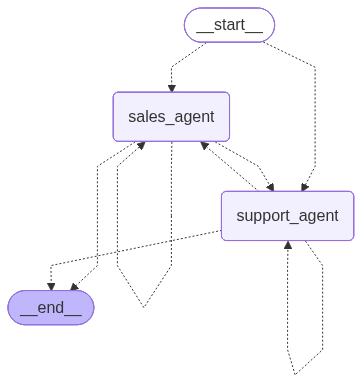

In [22]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
from langchain.messages import HumanMessage


result = graph.invoke(
    {
        "messages": [
            HumanMessage("Hi, I'm having trouble with my account login. Can you help?")
        ]
    },
    config={"configurable": { "thread_id": "1" }},
)

for msg in result["messages"]:
    msg.pretty_print()

================================ Human Message =================================

Hi, I'm having trouble with my account login. Can you help?
================================== Ai Message ==================================
Tool Calls:
  transfer_to_support_agent (call_11e6171ff3a547f6ac757dfb)
 Call ID: call_11e6171ff3a547f6ac757dfb
  Args:
================================= Tool Message =================================
Name: transfer_to_support_agent

Transferred to support_agent
================================== Ai Message ==================================

Sure, I can help with that. Could you let me know what’s happening when you try to log in? For example, are you seeing an error message, or is the login page just not loading? Any details you can share will help me troubleshoot the issue more quickly.


In [ ]:
result2 = graph.invoke(
    {
        "messages": [HumanMessage("I have some sales inquires")]
    },
    config={"configurable": { "thread_id": "1" }},
)

for msg in result2["messages"]:
    msg.pretty_print()

================================ Human Message =================================

Hi, I'm having trouble with my account login. Can you help?
================================== Ai Message ==================================
Tool Calls:
  transfer_to_support_agent (call_11e6171ff3a547f6ac757dfb)
 Call ID: call_11e6171ff3a547f6ac757dfb
  Args:
================================= Tool Message =================================
Name: transfer_to_support_agent

Transferred to support_agent
================================== Ai Message ==================================

Sure, I can help with that. Could you let me know what’s happening when you try to log in? For example, are you seeing an error message, or is the login page just not loading? Any details you can share will help me troubleshoot the issue more quickly.
================================ Human Message =================================

I have some sales inquires
================================== Ai Message =========================

## Implementation considerations

As you design your multi-agent system, consider:

* **Context filtering strategy**: Will each agent receive full conversation history, filtered portions, or summaries? Different agents may need different context depending on their role.
* **Tool semantics**: Clarify whether handoff tools only update routing state or also perform side effects. For example, should `transfer_to_sales()` also create a support ticket, or should that be a separate action?
* **Token efficiency**: Balance context completeness against token costs. Summarization and selective context passing become more important as conversations grow longer.